In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
from collections import defaultdict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
import os
import pandas as pd
import joblib
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import string
import re
source_dir = "Data"
output_dir = "Sorted_Emails"
spam_dir = os.path.join(output_dir, "spam")
not_spam_dir = os.path.join(output_dir, "not_spam")
os.makedirs(spam_dir, exist_ok=True)
os.makedirs(not_spam_dir, exist_ok=True)
for filename in os.listdir(source_dir):
    if not filename.endswith(".txt"):
        continue

    file_path = os.path.join(source_dir, filename)
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        content = f.read().lower()
    if "spm" in filename.lower() or "spam" in content:
        dest_path = os.path.join(spam_dir, filename)
    else:
        dest_path = os.path.join(not_spam_dir, filename)
    os.rename(file_path, dest_path)
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 1. Frame the problem
Using the customer description, Define the problem your trying to solve in your own words (remember this is not technial but must be specific so the customer understands the project

Using Machine Learning create a model that will be able to sort an email between spam and not spam. 

# 2. Get the Data 
Define how you recieved the data (provided, gathered..)

It was provided to me

# 3. Explore the Data
Gain insights into the data you have from step 2, making sure to identify any bias

I noticed that some words were primarily present in the Spam Word Map especially the word "Link". I also calculated the average length of the emails which indicates the typical form of spam and not spam emails. . 

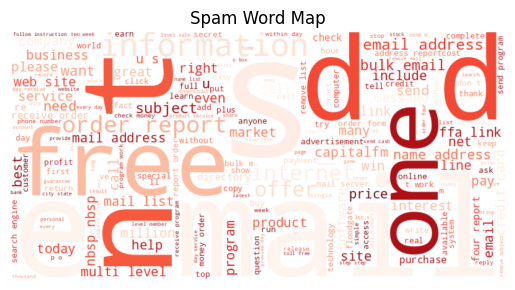

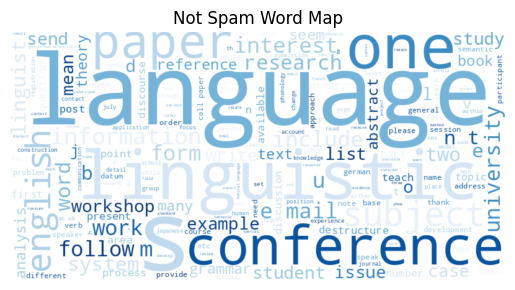

In [17]:
spam_dir = "Sorted_Emails/spam"
not_spam_dir = "Sorted_Emails/not_spam"
def combine_text(folder):
    text = ""
    for file in os.listdir(folder):
        if file.endswith(".txt"):
            with open(os.path.join(folder, file), "r", encoding="utf-8", errors="ignore") as f:
                content = f.read().lower()
                content = re.sub(r"[^a-z\s]", " ", content)
                text += " " + content
    return text
spam_text = combine_text(spam_dir)
not_spam_text = combine_text(not_spam_dir)

spam_map = WordCloud(width=800, height=400, background_color="white", colormap="Reds").generate(spam_text)
not_spam_map = WordCloud(width=800, height=400, background_color="white", colormap="Blues").generate(not_spam_text)

plt.imshow(spam_map, interpolation="bilinear")
plt.title("Spam Word Map")
plt.axis("off")
plt.show()

plt.imshow(not_spam_map, interpolation="bilinear")
plt.title("Not Spam Word Map")
plt.axis("off")
plt.show()

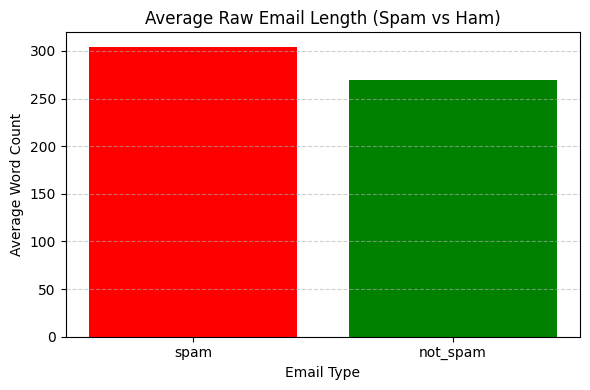

In [18]:
path = "Sorted_Emails"
labels = ["spam", "not_spam"]

def avg_word_count_raw(folder):
    results = {}
    for label in labels:
        path = os.path.join(folder, label)
        word_counts = []
        for file in os.listdir(path):
            file_path = os.path.join(path, file)
            if os.path.isfile(file_path):
                with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                    text = f.read()
                    tokens = text.split()
                    if len(tokens) > 0:
                        word_counts.append(len(tokens))
        avg_len = sum(word_counts) / len(word_counts) if word_counts else 0
        results[label] = avg_len
    return results
averages = avg_word_count_raw(path)
plt.figure(figsize=(6,4))
plt.bar(averages.keys(), averages.values(), color=['red', 'green'])
plt.title("Average Raw Email Length (Spam vs Ham)")
plt.xlabel("Email Type")
plt.ylabel("Average Word Count")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 4.Prepare the Data


Apply any data transformations and explain what and why


Im getting rid of stop words which are words that connect ideas but don't meaning fully contribute to them this way the model can ignore them while training. I also split up the data into spam and not spam initially. I also set up a vectorizer so I can feed the data into my model. I created a data frame as well just so I can put the data in my model. I created a tokenizer but it wasn't necessary. 

In [19]:
stopwords = {
    "a","about","above","after","again","against","all","am","an","and","any","are",
    "as","at","be","because","been","before","being","below","between","both","but",
    "by","can","did","do","does","doing","down","during","each","few","for","from",
    "further","had","has","have","having","he","her","here","hers","herself","him",
    "himself","his","how","i","if","in","into","is","it","its","itself","just","me",
    "more","most","my","myself","no","nor","not","of","off","on","once","only","or",
    "other","our","ours","ourselves","out","over","own","same","she","should","so",
    "some","such","than","that","the","their","theirs","them","themselves","then",
    "there","these","they","this","those","through","to","too","under","until","up",
    "very","was","we","were","what","when","where","which","while","who","whom",
    "why","will","with","you","your","yours","yourself","yourselves"
}

In [20]:
def remove_stopwords_in_file(path):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read().lower()
        text = re.sub(r"[^a-z\s]", " ", text)
        words = text.split()
        cleaned_words = [w for w in words if w not in stopwords]
    cleaned_text = " ".join(cleaned_words)
    with open(path, "w", encoding="utf-8") as f:
        f.write(cleaned_text)

for folder in [spam_dir, not_spam_dir]:
    for filename in os.listdir(folder):
        if filename.endswith(".txt"):
            remove_stopwords_in_file(os.path.join(folder, filename))

In [21]:
def clean_file(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [22]:
def tokenize(text):
    text = text.lower()
    text = re.sub(rf"[{re.escape(string.punctuation)}0-9]"," ", text)
    tokens = text.split()
    return tokens
texts = []
labels = []

for folder, label in [(spam_dir, "spam"), (not_spam_dir, "not_spam")]:
    for file in os.listdir(folder):
        if file.endswith(".txt"):
            with open(os.path.join(folder, file), "r", encoding="utf-8", errors="ignore") as f:
                texts.append(clean_file(f.read()))
                labels.append(label)

data_frame = pd.DataFrame({"text": texts, "target_name": labels})

# 5. Model the data
Using selected ML models, experment with your choices and describe your findings. Finish by selecting a Model to continue with


I initially started with MultiNomialNB. The reason I chose it is because it specializes in text classfication which the project requires. The implementation I used was incredibly basic but it resulted in a 96% accuracy score. 

In [23]:
class LaplaceSmoothing:
    def __init__(self, corpus):
        self.unigrams = defaultdict(int)
        self.bigrams = defaultdict(int)
        self.total_unigrams = 0
        self.vocab_size = 0

        self.train(corpus)

    def train(self, corpus):
        vocab = set()
        for sentence in corpus:
            tokens = sentence.split()
            vocab.update(tokens)
            for i in range(len(tokens)):
                self.unigrams[tokens[i]] += 1
                self.total_unigrams += 1
                if i > 0:
                    self.bigrams[(tokens[i-1], tokens[i])] += 1

        self.vocab_size = len(vocab)

    def bigram_prob(self, word1, word2):
        return (self.bigrams[(word1, word2)] + 1) / (self.unigrams[word1] + self.vocab_size)

In [24]:
class LidstoneSmoothing(LaplaceSmoothing):
    def __init__(self, corpus, lambda_=0.5):
        self.lambda_ = lambda_
        super().__init__(corpus)

    def bigram_prob(self, word1, word2):
        return (self.bigrams[(word1, word2)] + self.lambda_) / (self.unigrams[word1] + self.lambda_ * self.vocab_size)

In [30]:
x = data_frame["text"]
y = data_frame["target_name"]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.2,random_state=6)
vectorizer = TfidfVectorizer()
x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)
model = MultinomialNB()
#model = LidstoneSmoothing(corpus, lambda_=0.5)
model.fit(x_train_tfidf, y_train)
y_pred = model.predict(x_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
print(f"{accuracy*100:.3f}%")
print(y_pred)

98.286%
['spam' 'not_spam' 'spam' 'not_spam' 'not_spam' 'not_spam' 'spam' 'spam'
 'spam' 'not_spam' 'spam' 'spam' 'not_spam' 'not_spam' 'spam' 'spam'
 'not_spam' 'not_spam' 'not_spam' 'spam' 'not_spam' 'not_spam' 'not_spam'
 'spam' 'spam' 'spam' 'spam' 'spam' 'not_spam' 'not_spam' 'spam'
 'not_spam' 'spam' 'not_spam' 'spam' 'not_spam' 'not_spam' 'spam'
 'not_spam' 'not_spam' 'spam' 'not_spam' 'spam' 'spam' 'not_spam' 'spam'
 'not_spam' 'spam' 'spam' 'not_spam' 'not_spam' 'spam' 'spam' 'not_spam'
 'not_spam' 'not_spam' 'not_spam' 'not_spam' 'not_spam' 'not_spam' 'spam'
 'spam' 'spam' 'not_spam' 'spam' 'not_spam' 'not_spam' 'not_spam'
 'not_spam' 'spam' 'not_spam' 'not_spam' 'not_spam' 'not_spam' 'spam'
 'not_spam' 'spam' 'not_spam' 'not_spam' 'not_spam' 'not_spam' 'not_spam'
 'not_spam' 'not_spam' 'not_spam' 'spam' 'not_spam' 'not_spam' 'spam'
 'spam' 'spam' 'not_spam' 'spam' 'not_spam' 'spam' 'not_spam' 'spam'
 'not_spam' 'spam' 'not_spam' 'not_spam' 'spam' 'not_spam' 'not_spam'
 'not_

# 6. Fine Tune the Model

With the select model descibe the steps taken to acheve the best rusults possiable 


During the Fine Tuning Process all I did was change the random state which brought my accuracy from a 98% to a 99%. 

In [26]:
x = data_frame["text"]
y = data_frame["target_name"]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.2,random_state=1)
vectorizer = TfidfVectorizer()
x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)
model = MultinomialNB(alpha=2.0)
model.fit(x_train_tfidf, y_train)
y_pred = model.predict(x_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
joblib.dump((vectorizer, model), "spam_ham_model.joblib")
print(f"{accuracy*100:.3f}%")

99.429%


# 7. Present
In a customer faceing Document provide summery of finding and detail approach taken


First, I sorted the data into spam and not spam folders. This helped with exploring the data as it made it easy to find noticiable patterns in each category. I noticed that the spam mails contained key words such as "link, free, offer, information" while the not spam emails contained something related to language. The spam emails were also longer on average. It is important to note that I removed stopwords,things that connect ideas but don't contribute to them, so the model could focus on key words. I started with multinomalNB as my first Model and it ended up working super well. As for fine tuning, I just changed the random state.

# 8. Launch the Model System
Define your production run code, This should be self susficent and require only your model pramaters 


In [27]:
def inference(model, test_file):
    vectorizer, loaded_model = joblib.load(model)
    test_file = clean_file(test_file)
    test_vec = vectorizer.transform([test_file])
    results = loaded_model.predict(test_vec)
    return results[0]

In [28]:
text1=" "
text2=" "
with open(os.path.join(spam_dir, "test_ordinary.txt"), "w", encoding="utf-8") as f:
    f.write(text1)
with open(os.path.join(not_spam_dir, "test_ham.txt"), "w", encoding="utf-8") as f:
    f.write(text2)

In [29]:
print(inference("spam_ham_model.joblib", text1))

not_spam
